In [ ]:
%load_ext autoreload
%autoreload 2

# Importing the modules

import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
# from solver_2DHcurl_1DH1_Copie import *
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

import Antenna_Desc_n_Plot as antenna

geom_mode = "2D" # "1D" or "2D" 
box_medium = "PLASMA" # "VACUUM" or "PLASMA" 

antenna_grill = None
if antenna_grill != None:
    antenna_grill = antenna.AntennaGrill(b_active=0.009, d_septa=0.002, d_gap=0.010)
    antenna_grill.add_module(num_active=10, delta_phi_deg=90, is_PAM=False)

    instructions = antenna_grill.generate_mesh_instructions()
    antenna.plot_antenna_blueprint(instructions)

solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, geom_mode, box_medium, antenna_grill)

n_e = 5.00e+18 m^-3
In LHCoupling class: n_para: 2.0+0.0j, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j


In [4]:
mesh = solver.build_mesh_with_PMLs()
solver.build_physics_Stix_B_field()

GF_E_field, Gamma_R, Gamma_T, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, geom_mode, box_medium)

geom_mode: 1D
box_medium: PLASMA
==== 
Lx_plasma: 5.00e-02m,   Lx_pml: 5.00e-02m,    Lx_tot: 1.00e-01m
Lx_wg = 0.00e+00m
Lz_antenna: 0.00e+00m, Lz_wall: 0.00e+00m
Lz_plasma: 1.22e-01m, Lz_pml: 0.00e+00m, Lz_tot: 1.22e-01m
==== 
n_∥: 2.0+0.0j,   λ_∥: 4.05e-02m 
n_⟂⁺:8.98+0.00j, λ_⟂⁺: 9.02e-03m 
n_⟂-:0.00+1.63j, λ_⟂⁻: 4.98e-02m
==== 
n_index_meshing: 8.98 
λ_meshing: 9.02e-03m 
maxh_plasma: 6.01e-04m
[DOMAIN 1D DEFINED]
[MESH GENERATED !]
==== 
#DoFs = 1553668
--- Solving the 3D vector linear system ---
==== 
w_size_R: 1.3531e-02m,    w_size_T: 6.0769e-02m
Gamma_R (Dynamic SWR) = 2.997e-04
Gamma_T (SWR) = 1.842e-04

--- Poynting Flux & Energy Conservation ---
Net Power Injected (Antenna): 3.0391e-01 W/m
Net Power Exiting to PMLs:    3.0389e-01 W/m
Plasma Bulk Conservation Error: 7.54e-03 %
Power Dissipated inside PML: 3.2211e-08 W/m
PML Thermodynamic Error:     1.00e+02 %


In [5]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
# run_folder_tot_path = "/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/" + run_folder_path
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260625_141856
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260625_141856


--- Extracting 2D Wave Map ---
Lz_plasma_src: 0.122, Lz_wall: 0.000, Lz_pml: 0.000, Lz_tot: 0.122
Bornes géométriques fixées
  --> Pure Multithreaded C++ vectorized interpolation...
n_e = 5.00e+18 m^-3
In LHCoupling class: n_para: 2.0+0.0j, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
n_e = 5.00e+18 m^-3
PP_run_n_save: n_para: 2.0+0.0j, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260625_141856/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui

PRINT H5 METADATA:
 Lx_plasma: 5.00e-02
 Lx_pml: 5.00e-02
 Lx_tot: 1.00e-01
 Lz_plasma: 1.22e-01
 Lz_pml: 0.00e+00
 Lz_tot: 1.22e-01
 P_in_net: 3.04e-01
 eta_pred_R: 8.26e-11
 eta_pred_T: 1.00e+00
 eta_sim_R: 3.00e-04
 eta_sim_T: 1.84e-04
 k_para: (-155.09253162442445+0j)
 k_perp_p: (-696.5228085516777+0j)
 lambda_perp_real: 9.02e-03
 n_para_imag: 0.00e+00
 n_para_real: 2.00e+00
 peak_x_T: 2.27e-03
 peak_z_R: 3.

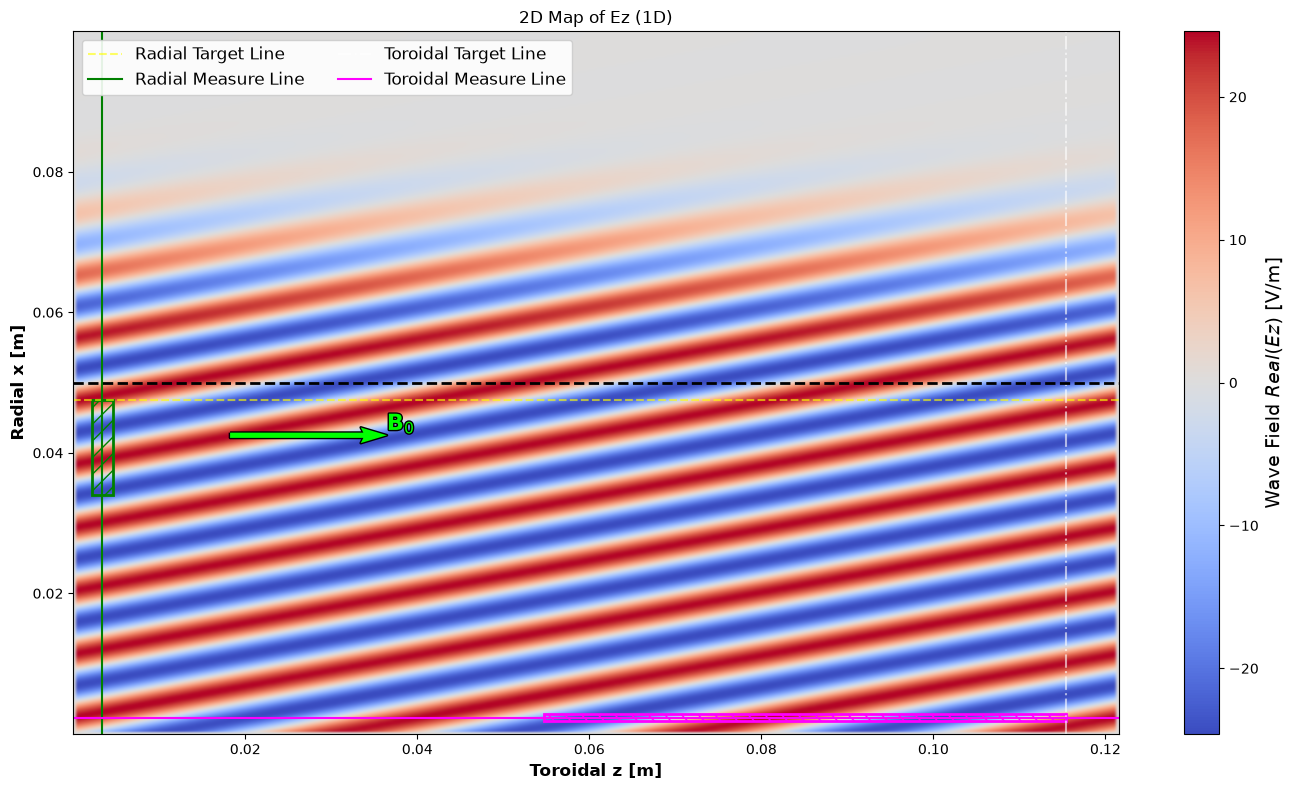

In [6]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, geom_mode, box_medium, antenna_grill, diag_data)
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 
# Plot E field 2D map and save it in the same folder: Run_XXX 
Lx_wg = cfg.DOMAIN.get('Lx_wg', 0.03)
Lz_wall = cfg.DOMAIN.get('Lz_wall', 0.02)

pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, geom_mode, component='Ez', value_type='real',
                         antenna_grill=antenna_grill, Lx_wg=Lx_wg, Lz_wall=Lz_wall, plot_poynting=False, show_windows=True, Poynting_box=False)

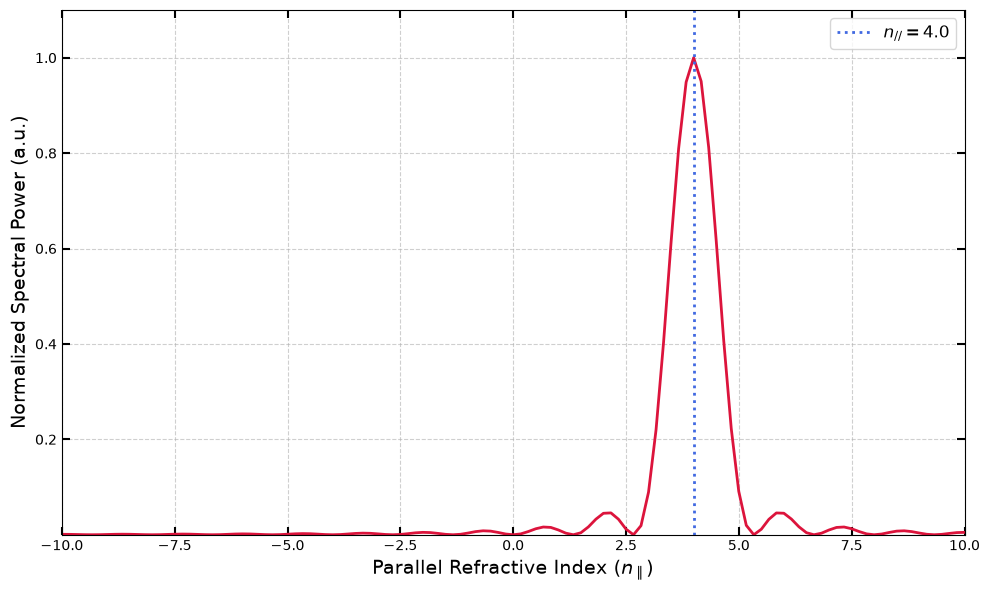

In [ ]:
# Test n_para spectrum

n_para_array, power_spectrum = pp_plot.plot_n_para_spectrum(mesh, GF_E_field, cfg, geom_mode, x_eval=0.015)


In [ ]:
import sweep_param_functions as spf

db_filepath = spf.generate_1D_radial_pml_database(cfg.__dict__, geom_mode, box_medium,save_dir="Simulation_Results")

  GÉNÉRATION DATABASE : PML RADIALE 1D (JACQUOT 2013) 

---> Lancement du balayage : Sweep_Sx_real (Sx_r)
  >> Test pour n_para = 2.0
n_e = 5.00e+18 m^-3
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
geom_mode: 1D
box_medium: PLASMA
==== 
Lx_plasma: 5.00e-02m,   Lx_pml: 5.00e-02m,    Lx_tot: 1.00e-01m
Lx_wg = 0.00e+00m
Lz_antenna: 0.00e+00m, Lz_wall: 0.00e+00m
Lz_plasma: 1.22e-01m, Lz_pml: 0.00e+00m, Lz_tot: 1.22e-01m
==== 
n_∥: 2.0,   λ_∥: 4.05e-02m 
n_⟂⁺:8.98+0.00j, λ_⟂⁺: 9.02e-03m 
n_⟂-:0.00+1.63j, λ_⟂⁻: 4.98e-02m
==== 
n_index_meshing: 8.98 
λ_meshing: 9.02e-03m 
maxh_plasma: 6.01e-04m
[DOMAIN 1D DEFINED]
[MESH GENERATED !]
==== 
#DoFs = 1573517
--- Solving the 3D vector linear system ---
==== 
w_size_R: 1.3531e-02m,    w_size_T: 6.0769e-02m
Gamma_R (Dynamic SWR) = 2.931e-04
Gamma_T (SWR) = 1.812e-04
==== 
Net Power Flow (W/m) => P_in: 3.0391e-01 | P_out_top: 3.0389e-01 
P_out_right: 7.7657e-01 | P_out_T_left: 7.7657e-01
type(P_ideal):

--- Création des graphiques multi-spectres depuis : Simulation_Results/PML_Radial_1D_Database_20260625_134013.h5 ---
param_values: [0.2  2.35 4.5 ]
  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_Lpml_Ratio.png


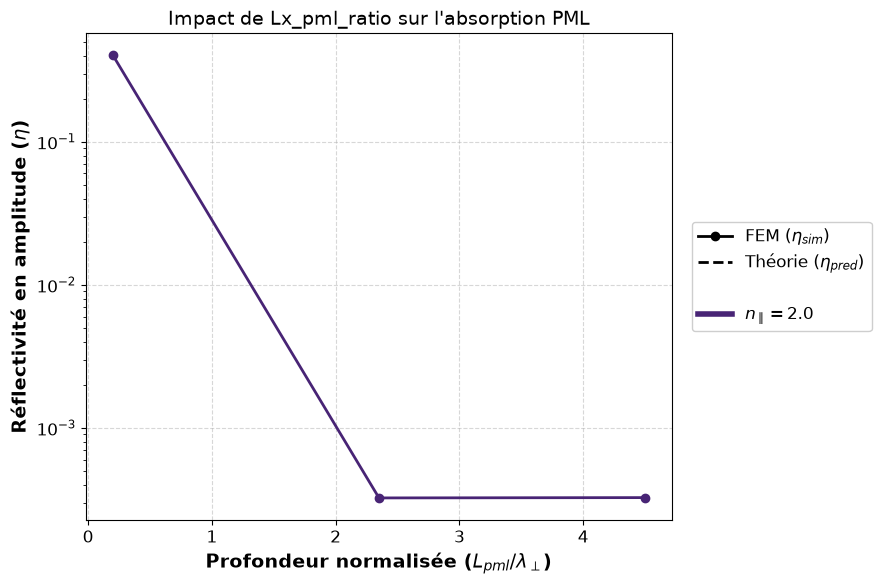

param_values: [10. 35. 60.]
  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_Resolution_PPW.png


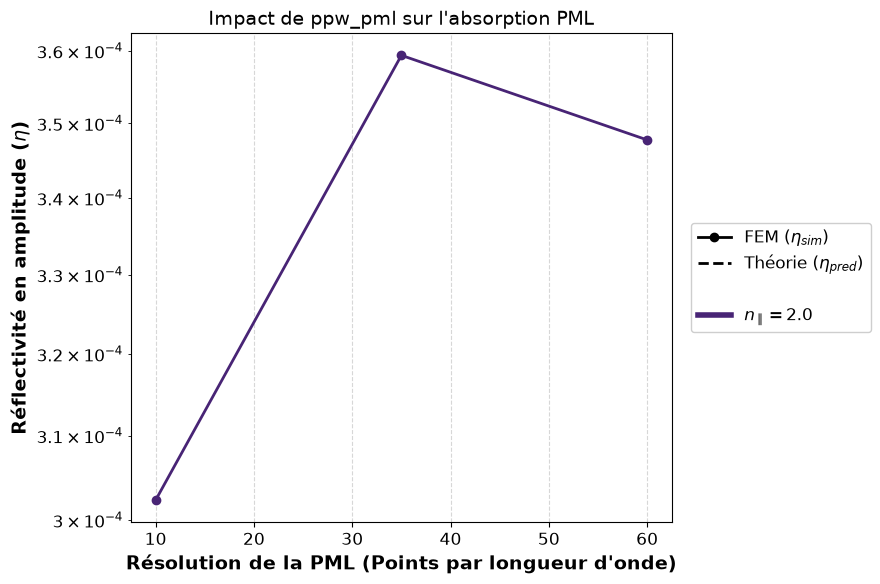

param_values: [10. 35. 60.]
  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_Resolution_PPW_Medium.png


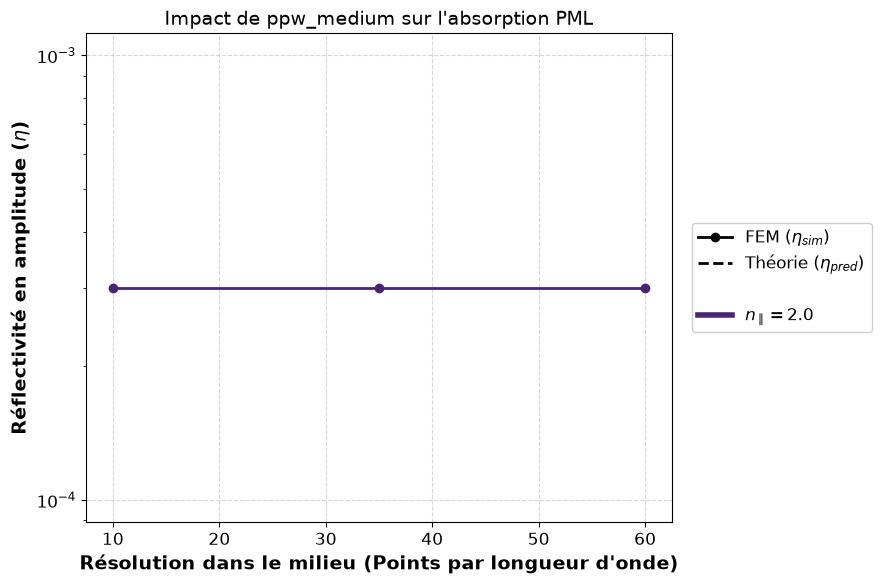

param_values: [ 0.5   6.25 12.  ]
  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_Sx_imag.png


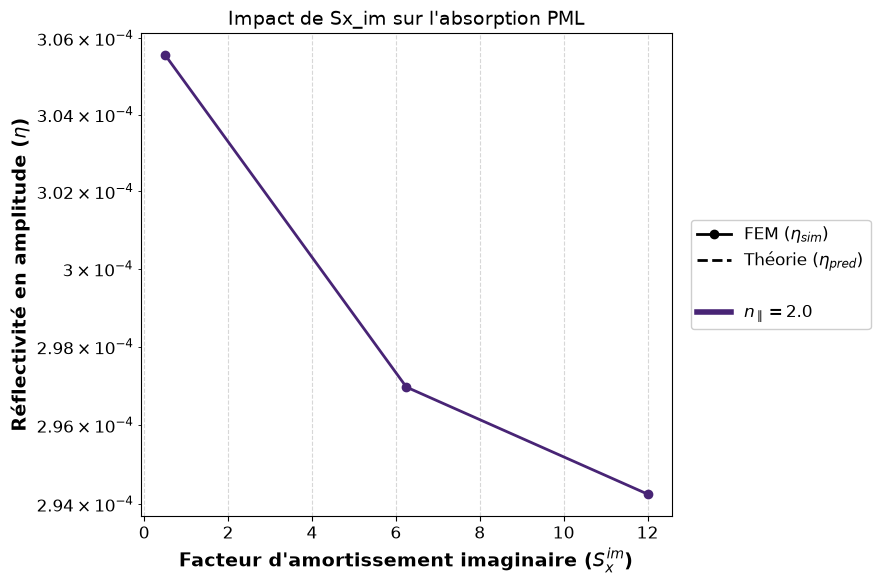

param_values: [0.5  2.75 5.  ]
  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_Sx_real.png


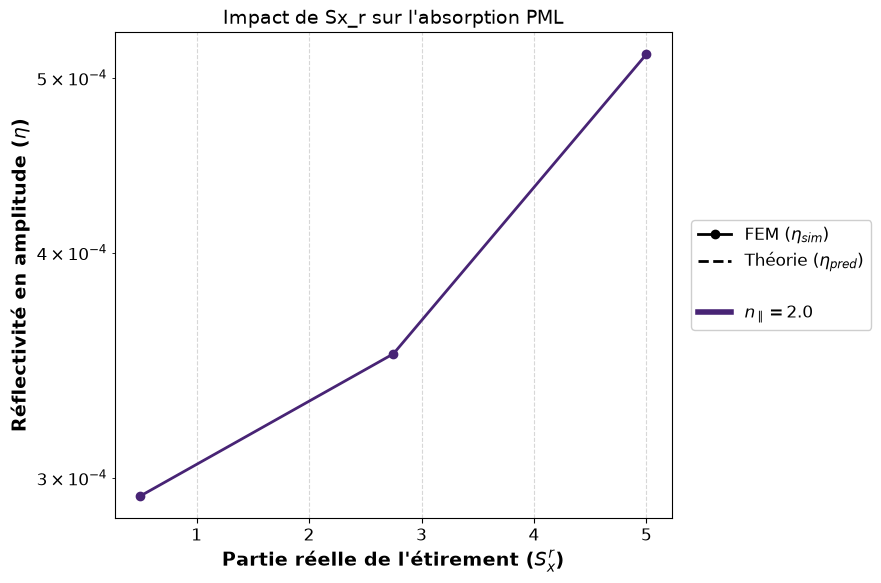

param_values: [1. 3. 5.]
  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_px.png


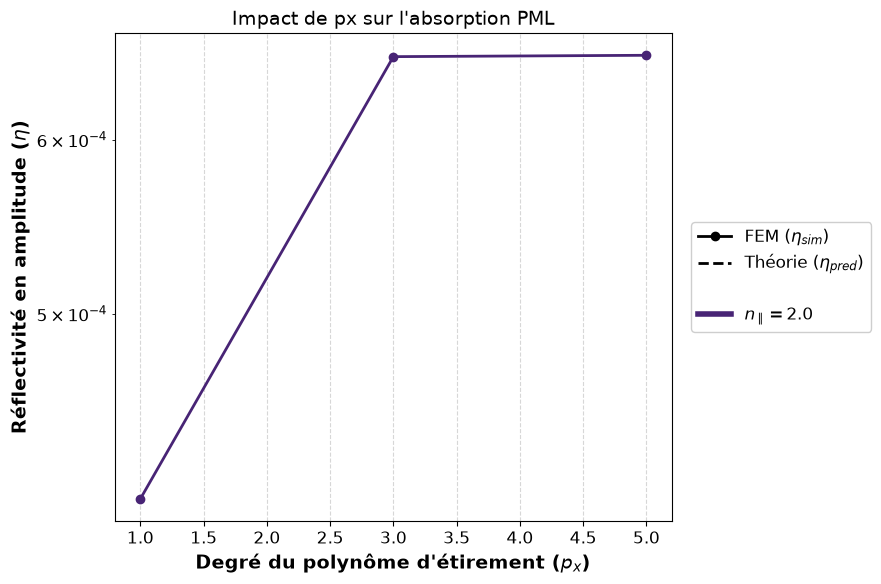

In [ ]:
# Vide 1D 40 pts: Simulation_Results/PML_1D_VACUUM_40pts.h5

spf.plot_sweeps_all_npara(db_filepath)